In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_predict


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

import optuna


# Data Manipulation and Pre-processing

In [3]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("match_data.csv")

In [4]:
# Remove suspended or stopped matches
df = df[~(df['suspended'] | df['stopped'])].copy()

# Exclude the additional times
df = df[df['minute'] < 45]

# Convert the minutes of 2nd half to the exact minute
df['minute'] = df.apply(lambda row: row['minute'] + 45 if row['halftime'] == '2nd-half' else row['minute'], axis=1)

# Create probability columns
df["Prob_1"] = 1 / df["1"]
df["Prob_2"] = 1 / df["2"]
df["Prob_X"] = 1 / df["X"]

# Make sure that the current_time column is a datetime object
df['current_time'] = pd.to_datetime(df['current_time'])

# Encode the target column for predictio: 1 -> 0, 2 -> 1, X -> 2
label_encoder = LabelEncoder()
df["result"] = label_encoder.fit_transform(df["result"])

# Fill NA data with 0
df = df.fillna(0)

# Add two new features that incorporates the previous  victory ratios for Home and Away
df[['Home - Team', 'Away - Team']] = df['name'].str.split(' vs ', expand=True)
df["date"] = df["current_time"].dt.date
df_win_ratio_calculation = df[["date",'Home - Team', 'Away - Team',"result","fixture_id"]]
df_win_ratio_calculation=df_win_ratio_calculation.drop_duplicates()

def calculate_win_ratio(matches, is_home):
    if matches.empty:
        return 0.0
    wins = matches['result'].eq(0 if is_home else 1).sum()
    return wins / len(matches)

df_win_ratio_calculation['home_win_ratio'] = df_win_ratio_calculation.apply(lambda row: calculate_win_ratio(
    df_win_ratio_calculation[(df_win_ratio_calculation['Home - Team'] == row['Home - Team']) & 
             (df_win_ratio_calculation['date'] < row['date']) & 
             (df_win_ratio_calculation['fixture_id'] != row['fixture_id'])], 
    is_home=True), axis=1)

df_win_ratio_calculation['away_win_ratio'] = df_win_ratio_calculation.apply(lambda row: calculate_win_ratio(
    df_win_ratio_calculation[(df_win_ratio_calculation['Away - Team'] == row['Away - Team']) & 
             (df_win_ratio_calculation['date'] < row['date']) & 
             (df_win_ratio_calculation['fixture_id'] != row['fixture_id'])], 
    is_home=False), axis=1)

df = df.merge(df_win_ratio_calculation,on=['date','Home - Team','Away - Team','result','fixture_id'],how="left")

In [5]:
# Split to train and test set
df_train = df[df['current_time'] <= '2024-11-01']
df_test = df[df['current_time'] > '2024-11-01']

In [6]:
# Classify the match according to the probabilites of the home and away team in the beginning of the match

def classify_match(group):
    first_row = group.iloc[0]
    prob_diff = abs(first_row['Prob_1'] - first_row['Prob_2'])
    
    # Apply clustering logic
    if prob_diff <= 0.1:
        cluster = 0 # Close strength matches
    elif 0.1 < prob_diff <= 0.4: 
        cluster = 1 # In between
    else:
        cluster = 2 # One of the dominates

    group['cluster'] = cluster
    return group

# Apply the classification logic to each match
df_train = df_train.groupby('fixture_id', group_keys=False).apply(classify_match)
df_test = df_test.groupby('fixture_id', group_keys=False).apply(classify_match)

df_train_0 = df_train[df_train['cluster'] == 0]
df_train_1 = df_train[df_train['cluster'] == 1]
df_train_2 = df_train[df_train['cluster'] == 2]

df_test_0 = df_test[df_test['cluster'] == 0]
df_test_1 = df_test[df_test['cluster'] == 1]
df_test_2 = df_test[df_test['cluster'] == 2]

# Determining the Model and Minutes

In [7]:
features = ["Assists - away", "Assists - home", "Attacks - away", "Attacks - home",
            "Ball Possession % - away", "Ball Possession % - home", "Challenges - away",
            "Challenges - home", "Goal Attempts - away", "Goal Attempts - home",
            "Goals - away", "Goals - home", "Penalties - away", "Penalties - home",
            "Redcards - away", "Redcards - home", "Saves - away", "Saves - home",
            "Shots On Target - away", "Shots On Target - home", 'Prob_1', 'Prob_2', 'Prob_X', 
            'home_win_ratio','away_win_ratio']

target = 'result'

In [8]:
data_results = []

define_clusters = {0: df_train_0, 1: df_train_1, 2: df_train_2}

for cluster, cluster_data in define_clusters.items():
    for minute in range(10,45):  # Iterate over each minutes (10 to 45)

        # Filter data for the specific minute
        minute_data = cluster_data[cluster_data['minute'] == minute]

        # Validation split based on current_time
        train_data = minute_data[minute_data['current_time'] < "2024-10-19"]
        val_data = minute_data[minute_data['current_time'] >= "2024-10-19"]

        # Check for single-class training data
        if len(train_data[target].unique()) == 1:
            print(f"Skipping Cluster {cluster}, Minute {minute}: Single class in training data")
            continue

        # Prepare features and targets
        X_train, y_train = train_data[features], train_data[target]
        X_val, y_val = val_data[features], val_data[target]
        val_odds = val_data[["Prob_1", "Prob_2", "Prob_X"]]

        # Define models
        models = {
            "Decision Tree": DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42),
            "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42),
            "XGBoost": XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42),
            "SVM": SVC(kernel="rbf", C=1.0, probability=False, random_state=42)
        }

        # Train and evaluate each model
        for model_name, model in models.items():
            
            if model_name == "SVM":
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                
                # Cross-validation score
                cv_accuracy = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy").mean()
                
                # Train the model
                model.fit(X_train_scaled, y_train)

                # Make predictions on the validation set
                X_val_scaled = scaler.fit_transform(X_val)
                y_val_pred = model.predict(X_val_scaled)
            
            else:
                
                # Cross-validation score
                cv_accuracy = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy").mean()
                
                # Train the model
                model.fit(X_train, y_train)

                # Make predictions on the validation set
                y_val_pred = model.predict(X_val)

            # Calculate profits
            profits = []
            for i in range(len(y_val)):
                profit = 0
                if y_val_pred[i] == y_val.iloc[i]:
                    predicted_class = (
                        "Prob_1" if y_val_pred[i] == 0 else
                        "Prob_2" if y_val_pred[i] == 1 else
                        "Prob_X"
                    )
                    profit += ((1 / val_odds.iloc[i][predicted_class]) - 1)
                else:
                    profit -= 1

                profits.append(profit)

            # Calculate metrics
            avg_profit = sum(profits) / len(profits) if len(profits) > 0 else 0

            # Store results
            data_results.append({
                "Cluster": cluster,
                "Minute": minute,
                "Model": model_name,
                "Average Profit": avg_profit,
                "CV_Accuracy": cv_accuracy
            })

# Convert results to DataFrame
results_df = pd.DataFrame(data_results)


## Cluster_0

/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


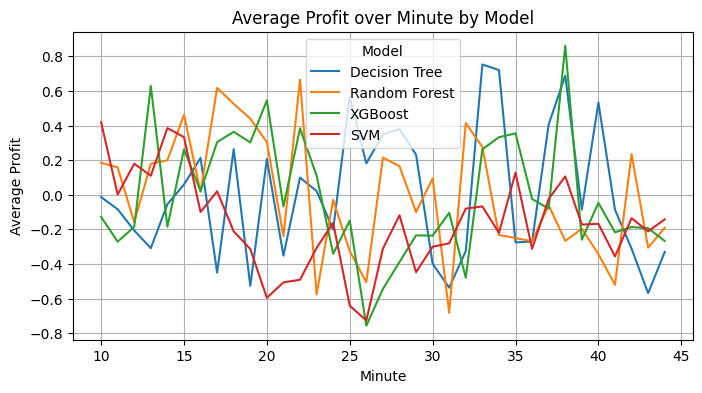

/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


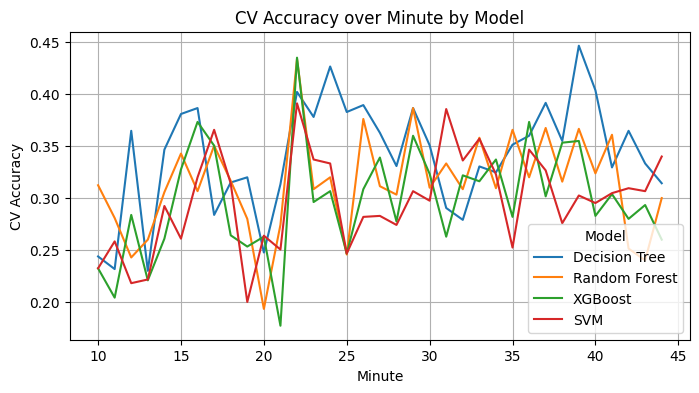

,Cluster,Minute,Model,Average Profit,CV_Accuracy
114,0,38,XGBoost,0.861000,0.353333
92,0,33,Decision Tree,0.752500,0.330476
96,0,34,Decision Tree,0.720500,0.324762
112,0,38,Decision Tree,0.688000,0.355000
49,0,22,Random Forest,0.665263,0.434066
14,0,13,XGBoost,0.629000,0.220833
29,0,17,Random Forest,0.617368,0.350476
60,0,25,Decision Tree,0.562941,0.382857
42,0,20,XGBoost,0.545556,0.262857
120,0,40,Decision Tree,0.532632,0.403810


In [52]:
cluster_data_0 = results_df[results_df['Cluster'] == 0]

# Plot Average Profit over Minute for different models
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=cluster_data_0,
    x='Minute',
    y='Average Profit',
    hue='Model'
)
plt.title('Average Profit over Minute by Model')
plt.xlabel('Minute')
plt.ylabel('Average Profit')
plt.legend(title='Model')
plt.grid(True)
plt.show()

# Plot CV Accuracy over Minute for different models
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=cluster_data_0,
    x='Minute',
    y='CV_Accuracy',
    hue='Model'
)
plt.title('CV Accuracy over Minute by Model')
plt.xlabel('Minute')
plt.ylabel('CV Accuracy')
plt.legend(title='Model')
plt.grid(True)
plt.show()

top_profits_0 = cluster_data_0.nlargest(10, "Average Profit")
top_profits_0


## Cluster_1

/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


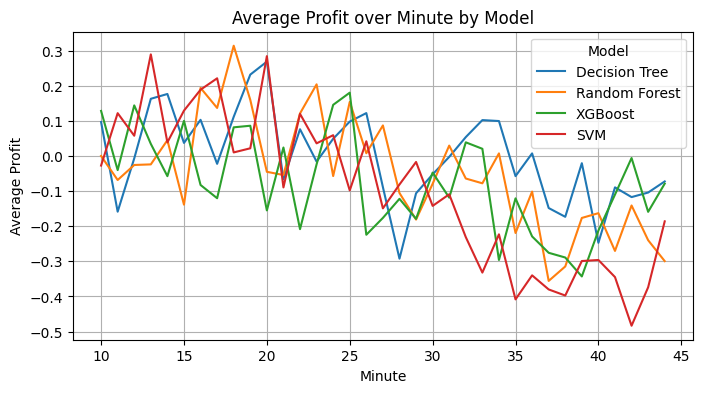

/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


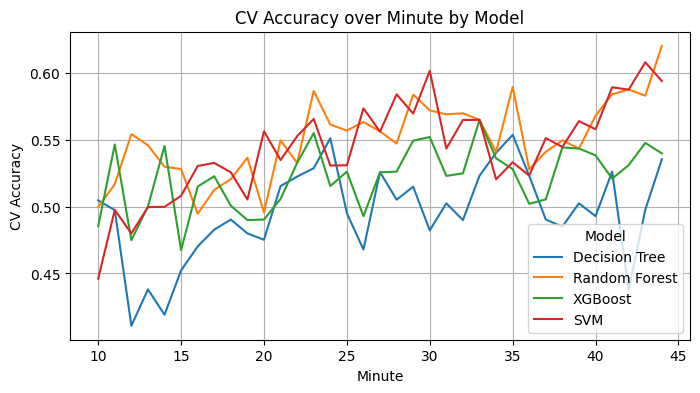

,Cluster,Minute,Model,Average Profit,CV_Accuracy
173,1,18,Random Forest,0.314655,0.520641
155,1,13,SVM,0.290000,0.499730
183,1,20,SVM,0.284909,0.556538
180,1,20,Decision Tree,0.269273,0.475256
176,1,19,Decision Tree,0.232321,0.480027
171,1,17,SVM,0.221786,0.532821
193,1,23,Random Forest,0.204576,0.586775
165,1,16,Random Forest,0.194483,0.494744
167,1,16,SVM,0.189310,0.530513
202,1,25,XGBoost,0.180862,0.526316


In [57]:
cluster_data_1 = results_df[results_df['Cluster'] == 1]

# Plot Average Profit over Minute for different models
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=cluster_data_1,
    x='Minute',
    y='Average Profit',
    hue='Model'
)
plt.title('Average Profit over Minute by Model')
plt.xlabel('Minute')
plt.ylabel('Average Profit')
plt.legend(title='Model')
plt.grid(True)
plt.show()

# Plot CV Accuracy over Minute for different models
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=cluster_data_1,
    x='Minute',
    y='CV_Accuracy',
    hue='Model'
)
plt.title('CV Accuracy over Minute by Model')
plt.xlabel('Minute')
plt.ylabel('CV Accuracy')
plt.legend(title='Model')
plt.grid(True)
plt.show()

top_profits_1 = cluster_data_1.nlargest(10, "Average Profit")
top_profits_1

## Cluster_2

/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


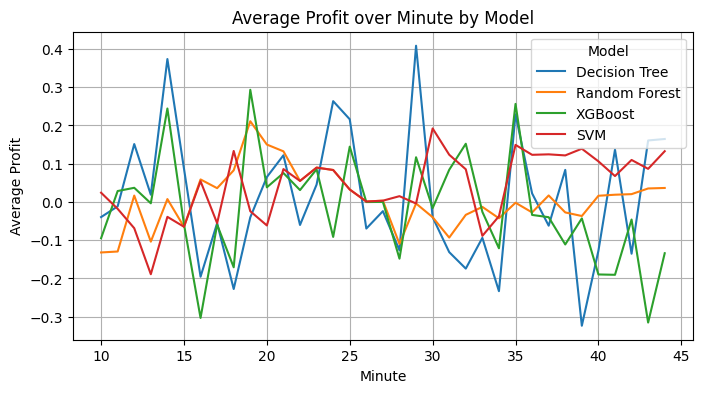

/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ahmetkarakose/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


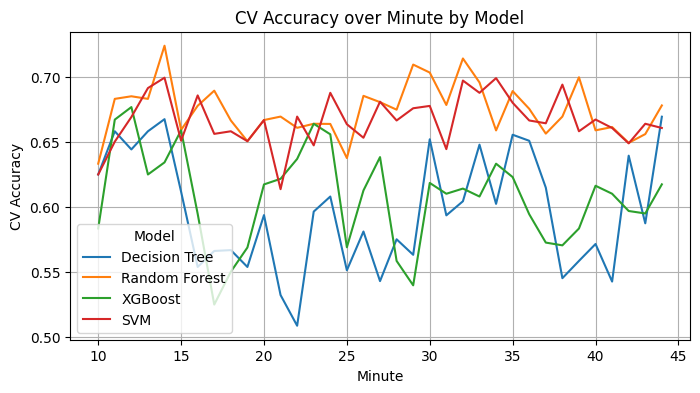

,Cluster,Minute,Model,Average Profit,CV_Accuracy
356,2,29,Decision Tree,0.408387,0.563043
296,2,14,Decision Tree,0.373548,0.667667
318,2,19,XGBoost,0.293125,0.568667
336,2,24,Decision Tree,0.263437,0.608000
382,2,35,XGBoost,0.256250,0.623000
298,2,14,XGBoost,0.244194,0.634333
380,2,35,Decision Tree,0.229063,0.655667
340,2,25,Decision Tree,0.216061,0.551087
317,2,19,Random Forest,0.210938,0.650667
363,2,30,SVM,0.192143,0.677899


In [59]:
cluster_data_2 = results_df[results_df['Cluster'] == 2]

# Plot Average Profit over Minute for different models
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=cluster_data_2,
    x='Minute',
    y='Average Profit',
    hue='Model'
)
plt.title('Average Profit over Minute by Model')
plt.xlabel('Minute')
plt.ylabel('Average Profit')
plt.legend(title='Model')
plt.grid(True)
plt.show()

# CV Accuracy over Minute for different models
plt.figure(figsize=(8, 4))
sns.lineplot(
    data=cluster_data_2,
    x='Minute',
    y='CV_Accuracy',
    hue='Model'
)
plt.title('CV Accuracy over Minute by Model')
plt.xlabel('Minute')
plt.ylabel('CV Accuracy')
plt.legend(title='Model')
plt.grid(True)
plt.show()

top_profits_2 = cluster_data_2.nlargest(10, "Average Profit")
top_profits_2

# Application on Test Set

In [55]:
def evaluate_model(X_train, X_test, y_train, y_test, model, odds_columns=None):

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    profits = []

    if odds_columns is not None:  
        for i in range(len(y_test)):
            profit = 0
            if y_pred[i] == y_test.iloc[i]:
                # Correct prediction: add the corresponding odd
                if y_pred[i] == 0:
                    predicted_class = "1"
                elif y_pred[i] == 1:
                    predicted_class = "2"
                else:
                    predicted_class = "X"

                profit += (odds_columns.iloc[i][predicted_class] - 1)  # Profit is odd minus 1
            else:
                # Incorrect prediction: subtract 1
                profit -= 1

            profits.append(profit)

    # Calculate metrics
    total_profit = sum(profits) if odds_columns is not None else None
    average_profit = total_profit / len(y_test) if odds_columns is not None else None
    accuracy = accuracy_score(y_test, y_pred)
    total_bets = len(y_test)

    results = {
    "Total Profit": total_profit,
    "Average Profit per Bet": average_profit,
    "Accuracy": accuracy,
    "Total Bets": total_bets
}

    results_df = pd.DataFrame([results])
    return results_df

In [13]:
# Select the features and target variable
features = ["Assists - away", "Assists - home", "Attacks - away", "Attacks - home",
            "Ball Possession % - away", "Ball Possession % - home", "Challenges - away",
            "Challenges - home", "Goal Attempts - away", "Goal Attempts - home",
            "Goals - away", "Goals - home", "Penalties - away", "Penalties - home",
            "Redcards - away", "Redcards - home", "Saves - away", "Saves - home",
            "Shots On Target - away", "Shots On Target - home", 'Prob_1', 'Prob_2', 'Prob_X', 'home_win_ratio','away_win_ratio']

target = 'result'

## Cluster_0

In [45]:
df_train_0_min = df_train_0[df_train_0["minute"] == 34]

X_train = df_train_0_min[features]
y_train = df_train_0_min[target]

def objective(trial):
    # Suggest hyperparameters
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 5),  # Maximum depth of the tree
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),  # Minimum samples to split a node
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),  # Minimum samples in a leaf node
    }
    
    # Initialize the Decision Tree model
    dt_model = DecisionTreeClassifier(**params, random_state=42)
    
    # Perform cross-validation and calculate the mean accuracy
    cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring="accuracy")  # 5-fold CV
    return cv_scores.mean()  # Return the average accuracy across folds

# Run Optuna optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

# Get the best parameters
best_params_dt = study.best_params
print("Best Hyperparameters:", best_params_dt)


[I 2025-01-13 17:47:07,682] A new study created in memory with name: no-name-54f428f3-bb0f-48e3-9ea4-fe77d2cdf2e6
[I 2025-01-13 17:47:07,697] Trial 0 finished with value: 0.45964912280701753 and parameters: {'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.45964912280701753.
[I 2025-01-13 17:47:07,710] Trial 1 finished with value: 0.4052631578947368 and parameters: {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.45964912280701753.
[I 2025-01-13 17:47:07,718] Trial 2 finished with value: 0.42748538011695913 and parameters: {'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.45964912280701753.
[I 2025-01-13 17:47:07,727] Trial 3 finished with value: 0.38421052631578945 and parameters: {'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.45964912280701753.
[I 2025-01-13 17:47:07,735] Trial 4 finished with value: 0.

Best Hyperparameters: {'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 5}


In [56]:
df_train_0_min = df_train_0[df_train_0["minute"] == 34]
df_test_0_min = df_test_0[df_test_0["minute"] == 34]

X_train_0 = df_train_0_min[features]
X_test_0 = df_test_0_min[features]
y_train_0 = df_train_0_min[target]
y_test_0 = df_test_0_min[target]

X_test_odds_0 = df_test_0_min[["1", "2", "X"]]

best_model_0 = DecisionTreeClassifier(**best_params_dt, random_state=42)

# Modeli değerlendir
cluster_0_results = evaluate_model(X_train_0, X_test_0, y_train_0, y_test_0, best_model_0, X_test_odds_0)
cluster_0_results

,Total Profit,Average Profit per Bet,Accuracy,Total Bets
0,1.09,0.060556,0.333333,18


## Cluster_1

In [16]:
df_train_1_min = df_train_1[df_train_1["minute"] == 20]

# Split the data into training and validation sets based on "current_time"
X_train = scaler.fit_transform(df_train_1_min[features])
y_train = df_train_1_min[target]


# Define the objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    params = {
        "C": trial.suggest_float("C", 0.1, 5, log=True),  # Regularization parameter
        "gamma": trial.suggest_categorical("gamma", ["scale", "auto"])  # Kernel coefficient
    }
    
    # Initialize the SVM model with RBF kernel
    svm_model = SVC(kernel='rbf', probability=False, **params, random_state=42)
    
    # Perform cross-validation and calculate the mean accuracy
    cv_scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring="accuracy")  # 5-fold CV
    return cv_scores.mean()  # Return the average accuracy across folds

# Run Optuna optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

# Get the best parameters
best_params_svm = study.best_params
print("Best Hyperparameters:", best_params_svm)

[I 2025-01-13 14:15:53,767] A new study created in memory with name: no-name-0f4b78f4-a2c5-47f6-b958-da00de3765bc
[I 2025-01-13 14:15:53,780] Trial 0 finished with value: 0.5138823529411765 and parameters: {'C': 2.6657127876157856, 'gamma': 'scale'}. Best is trial 0 with value: 0.5138823529411765.
[I 2025-01-13 14:15:53,792] Trial 1 finished with value: 0.5258823529411765 and parameters: {'C': 1.5270094909945786, 'gamma': 'scale'}. Best is trial 1 with value: 0.5258823529411765.
[I 2025-01-13 14:15:53,803] Trial 2 finished with value: 0.48235294117647065 and parameters: {'C': 0.13239543485022276, 'gamma': 'scale'}. Best is trial 1 with value: 0.5258823529411765.
[I 2025-01-13 14:15:53,849] Trial 3 finished with value: 0.5058039215686275 and parameters: {'C': 3.8237807103216954, 'gamma': 'auto'}. Best is trial 1 with value: 0.5258823529411765.
[I 2025-01-13 14:15:53,870] Trial 4 finished with value: 0.5378823529411765 and parameters: {'C': 1.4332095422722866, 'gamma': 'auto'}. Best is t

Best Hyperparameters: {'C': 0.6328690346059431, 'gamma': 'scale'}


In [58]:
df_train_1_min = df_train_1[df_train_1["minute"] == 20]
df_test_1_min = df_test_1[df_test_1["minute"] == 20]


# Split the data into training and validation sets based on "current_time"
X_train_1 = scaler.fit_transform(df_train_1_min[features])
X_test_1 = scaler.fit_transform(df_test_1_min[features])
y_train_1 = df_train_1_min[target]
y_test_1 = df_test_1_min[target]

X_test_odds_1 = df_test_1_min[["1","2","X"]]
best_model_1 = SVC(**best_params_svm, random_state=42)

cluster_1_results = evaluate_model(X_train_1, X_test_1, y_train_1, y_test_1, best_model_1, X_test_odds_1)
cluster_1_results

,Total Profit,Average Profit per Bet,Accuracy,Total Bets
0,0.15,0.00283,0.490566,53


## Cluster_2

In [18]:
df_train_2_min = df_train_2[df_train_2["minute"] == 14]

X_train = df_train_2_min[features]
y_train = df_train_2_min[target]

def objective(trial):
    # Suggest hyperparameters
    params = {
        "max_depth": trial.suggest_int("max_depth", 4,4),  # Maximum depth of the tree
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),  # Minimum samples to split a node
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),  # Minimum samples in a leaf node
    }
    
    # Initialize the Decision Tree model
    dt_model = DecisionTreeClassifier(**params, random_state=42)
    
    # Perform cross-validation and calculate the mean accuracy
    cv_scores = cross_val_score(dt_model, X_train, y_train, cv=5, scoring="accuracy")  # 5-fold CV
    return cv_scores.mean()  # Return the average accuracy across folds

# Run Optuna optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

# Get the best parameters
best_params_dt = study.best_params
print("Best Hyperparameters:", best_params_dt)

[I 2025-01-13 14:15:54,208] A new study created in memory with name: no-name-6eb38d66-a7a6-4e7d-a4b0-7248c720658d
[I 2025-01-13 14:15:54,217] Trial 0 finished with value: 0.6625806451612902 and parameters: {'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.6625806451612902.
[I 2025-01-13 14:15:54,226] Trial 1 finished with value: 0.6625806451612902 and parameters: {'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6625806451612902.
[I 2025-01-13 14:15:54,234] Trial 2 finished with value: 0.6625806451612902 and parameters: {'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.6625806451612902.
[I 2025-01-13 14:15:54,242] Trial 3 finished with value: 0.6625806451612902 and parameters: {'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.6625806451612902.
[I 2025-01-13 14:15:54,249] Trial 4 finished with value: 0.6559139

Best Hyperparameters: {'max_depth': 4, 'min_samples_split': 10, 'min_samples_leaf': 5}


In [60]:
df_train_2_min = df_train_2[df_train_2["minute"] == 14]
df_test_2_min = df_test_2[df_test_2["minute"] == 14]

X_train_0 = df_train_2_min[features]
X_test_0 = df_test_2_min[features]
y_train_0 = df_train_2_min[target]
y_test_0 = df_test_2_min[target]

X_test_odds_0 = df_test_2_min[["1", "2", "X"]]

best_model_0 = DecisionTreeClassifier(**best_params_dt, random_state=42)

cluster_2_results = evaluate_model(X_train_0, X_test_0, y_train_0, y_test_0, best_model_0, X_test_odds_0)
cluster_2_results

,Total Profit,Average Profit per Bet,Accuracy,Total Bets
0,0.75,0.024194,0.645161,31


## Initial Results

In [67]:
total_profit = cluster_0_results["Total Profit"][0] + cluster_1_results["Total Profit"][0] + cluster_2_results["Total Profit"][0]
total_bets = len(df_test_0_min) + len(df_test_1_min) + len(df_test_2_min)
total_predicted_correct = (len(df_test_0_min) * cluster_0_results["Accuracy"]) + (len(df_test_1_min) * cluster_1_results["Accuracy"]) + (len(df_test_2_min) * cluster_2_results["Accuracy"])
overall_accuracy = int(total_predicted_correct) / total_bets

results_initial = {
    "Metric": ["Total Profit", "Total Bets", "Overall Accuracy"],
    "Value": [total_profit, total_bets, overall_accuracy]
}

# Convert to a DataFrame
results_df = pd.DataFrame(results_initial)
results_df

/var/folders/dd/51tkdh2n1m5f0w9z63tq8qfr0000gn/T/ipykernel_81364/3446404433.py:4: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  overall_accuracy = int(total_predicted_correct) / total_bets


,Metric,Value
0,Total Profit,1.990000
1,Total Bets,102.000000
2,Overall Accuracy,0.509804


# Application of Meta Model

In [20]:
stacking_results = []

define_clusters = {0: df_train_0, 1: df_train_1, 2: df_train_2}

for cluster, cluster_data in define_clusters.items():
    for minute in range(10, 45):  # Iterate over minutes (10 to 45)

        # Filter data for the specific minute
        minute_data = cluster_data[cluster_data['minute'] == minute]

        # Validation split based on current_time
        train_data = minute_data[minute_data['current_time'] < "2024-10-19"]
        val_data = minute_data[minute_data['current_time'] >= "2024-10-19"]

        # Check for single-class training data
        if len(train_data[target].unique()) == 1:
            print(f"Skipping Cluster {cluster}, Minute {minute}: Single class in training data")
            continue

        # Prepare features and targets
        X_train, y_train = train_data[features], train_data[target]
        X_val, y_val = val_data[features], val_data[target]
        val_odds = val_data[["Prob_1", "Prob_2", "Prob_X"]]

        # Define base models
        base_models = [
            ("Decision Tree", DecisionTreeClassifier(max_depth=4, min_samples_split=10, random_state=42)),
            ("Random Forest", RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)),
            ("XGBoost", XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)),
            ("SVM", SVC(kernel="rbf", C=1.0, probability=True, random_state=42))
        ]

        # Prepare meta-model (Logistic Regression)
        meta_model = LogisticRegression(random_state=42)

        # Stacking classifier
        stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)

        # Scale data for SVM
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # Cross-validation score for stacking model
        cv_accuracy = cross_val_score(stacking_clf, X_train_scaled, y_train, cv=5, scoring="accuracy").mean()

        # Train the stacking model
        stacking_clf.fit(X_train_scaled, y_train)

        # Make predictions on the validation set
        y_val_pred = stacking_clf.predict(X_val_scaled)

        # Calculate profits
        profits = []
        for i in range(len(y_val)):
            profit = 0
            if y_val_pred[i] == y_val.iloc[i]:
                predicted_class = (
                    "Prob_1" if y_val_pred[i] == 0 else
                    "Prob_2" if y_val_pred[i] == 1 else
                    "Prob_X"
                )
                profit += ((1 / val_odds.iloc[i][predicted_class]) - 1)
            else:
                profit -= 1

            profits.append(profit)

        # Calculate metrics
        avg_profit = sum(profits) / len(profits) if len(profits) > 0 else 0

        # Store stacking results
        stacking_results.append({
            "Cluster": cluster,
            "Minute": minute,
            "Model": "Stacking",
            "Average Profit": avg_profit,
            "CV_Accuracy": cv_accuracy
        })

# Convert stacking results to DataFrame
stacking_results_df = pd.DataFrame(stacking_results)

stacking_results_df.sort_values(by="Average Profit", ascending=False, inplace=True)


In [21]:
cluster_0_stacking_top_10 = stacking_results_df[stacking_results_df["Cluster"]==0][:10]
cluster_0_stacking_top_10

,Cluster,Minute,Model,Average Profit,CV_Accuracy
11,0,21,Stacking,0.848947,0.326667
26,0,36,Stacking,0.656000,0.373333
28,0,38,Stacking,0.586500,0.236667
15,0,25,Stacking,0.575294,0.206667
8,0,18,Stacking,0.518947,0.356667
17,0,27,Stacking,0.484444,0.417143
16,0,26,Stacking,0.375556,0.308571
24,0,34,Stacking,0.258000,0.392381
33,0,43,Stacking,0.199500,0.360000
34,0,44,Stacking,0.173158,0.464762


In [22]:
cluster_1_stacking_top_10 = stacking_results_df[stacking_results_df["Cluster"]==1][:10]
cluster_1_stacking_top_10

,Cluster,Minute,Model,Average Profit,CV_Accuracy
44,1,19,Stacking,0.236429,0.505533
48,1,23,Stacking,0.163390,0.549933
41,1,16,Stacking,0.127241,0.494872
50,1,25,Stacking,0.116552,0.546424
51,1,26,Stacking,0.108571,0.518333
56,1,31,Stacking,0.089483,0.502564
43,1,18,Stacking,0.075172,0.510513
35,1,10,Stacking,0.054194,0.499878
58,1,33,Stacking,0.049107,0.524157
46,1,21,Stacking,0.048727,0.530000


In [23]:
cluster_2_stacking_top_10 = stacking_results_df[stacking_results_df["Cluster"]==2][:10]
cluster_2_stacking_top_10

,Cluster,Minute,Model,Average Profit,CV_Accuracy
75,2,15,Stacking,0.292000,0.643385
95,2,35,Stacking,0.229063,0.647667
78,2,18,Stacking,0.213226,0.633333
79,2,19,Stacking,0.187188,0.635000
81,2,21,Stacking,0.177097,0.637333
82,2,22,Stacking,0.168485,0.645333
103,2,43,Stacking,0.131935,0.638768
80,2,20,Stacking,0.128125,0.650667
74,2,14,Stacking,0.068710,0.707667
97,2,37,Stacking,0.016875,0.639493


In [24]:
features = ["Assists - away", "Assists - home", "Attacks - away", "Attacks - home",
            "Ball Possession % - away", "Ball Possession % - home", "Challenges - away",
            "Challenges - home", "Goal Attempts - away", "Goal Attempts - home",
            "Goals - away", "Goals - home", "Penalties - away", "Penalties - home",
            "Redcards - away", "Redcards - home", "Saves - away", "Saves - home",
            "Shots On Target - away", "Shots On Target - home", 'Prob_1', 'Prob_2', 'Prob_X','home_win_ratio','away_win_ratio']
target = 'result'

## Cluster_0

In [69]:
df_train_0_min_stacking = df_train_0[df_train_0["minute"] == 27]
df_test_0_min_stacking = df_test_0[df_test_0["minute"] == 27]


# Split the data into training and validation sets based on "current_time"
X_train_0 = df_train_0_min_stacking[features]
X_test_0 = df_test_0_min_stacking[features]
y_train_0 = df_train_0_min_stacking[target]
y_test_0 = df_test_0_min_stacking[target]

X_test_odds_0 = df_test_0_min_stacking[["1","2","X"]]
best_model_0 = stacking_clf

cluster_0_stacking_results = evaluate_model(X_train_0, X_test_0, y_train_0, y_test_0, best_model_0, X_test_odds_0)
cluster_0_stacking_results

,Total Profit,Average Profit per Bet,Accuracy,Total Bets
0,6.92,0.364211,0.473684,19


## Cluster_1

In [70]:
df_train_1_min_stacking = df_train_1[df_train_1["minute"] == 19]
df_test_1_min_stacking = df_test_1[df_test_1["minute"] == 19]


# Split the data into training and validation sets based on "current_time"
X_train_1 = df_train_1_min_stacking[features]
X_test_1 = df_test_1_min_stacking[features]
y_train_1 = df_train_1_min_stacking[target]
y_test_1 = df_test_1_min_stacking[target]

X_test_odds_1 = df_test_1_min_stacking[["1","2","X"]]
best_model_1 = stacking_clf

cluster_1_stacking_results = evaluate_model(X_train_1, X_test_1, y_train_1, y_test_1, best_model_1, X_test_odds_1)
cluster_1_stacking_results

,Total Profit,Average Profit per Bet,Accuracy,Total Bets
0,2.12,0.040769,0.480769,52


## Cluster_2

In [71]:
df_train_2_min_stacking = df_train_2[df_train_2["minute"] == 15]
df_test_2_min_stacking = df_test_2[df_test_2["minute"] == 15]


# Split the data into training and validation sets based on "current_time"
X_train_2 = df_train_2_min_stacking[features]
X_test_2 = df_test_2_min_stacking[features]
y_train_2 = df_train_2_min_stacking[target]
y_test_2 = df_test_2_min_stacking[target]

X_test_odds_2 = df_test_2_min_stacking[["1","2","X"]]
best_model_2 = stacking_clf

cluster_2_stacking_results = evaluate_model(X_train_2, X_test_2, y_train_2, y_test_2, best_model_2, X_test_odds_2)
cluster_2_stacking_results

,Total Profit,Average Profit per Bet,Accuracy,Total Bets
0,0.58,0.017059,0.735294,34


# Final Results

In [68]:
total_profit = cluster_0_stacking_results["Total Profit"] + cluster_1_stacking_results["Total Profit"] + cluster_2_stacking_results["Total Profit"]
total_bets = len(df_test_0_min_stacking) + len(df_test_1_min_stacking) + len(df_test_2_min_stacking)
total_predicted_correct = (len(df_test_0_min_stacking) * cluster_0_stacking_results["Accuracy"]) + (len(df_test_1_min_stacking) * cluster_1_stacking_results["Accuracy"]) + (len(df_test_2_min_stacking) * cluster_2_stacking_results["Accuracy"])
overall_accuracy = int(total_predicted_correct) / total_bets

results_final = {
    "Metric": ["Total Profit", "Total Bets", "Overall Accuracy"],
    "Value": [total_profit, total_bets, overall_accuracy]
}

# Convert to a DataFrame
results_df = pd.DataFrame(results_final)
results_df

,Metric,Value
0,Total Profit,9.620000
1,Total Bets,105.000000
2,Overall Accuracy,0.561905
